# Chapter 8. Data Wrangling: Join, Combine, and Reshape

## 8.1 Hierarchial Indexing
- Hierarchial indexing is an important feature of pandas that enables you to have multiple (two or more) index levels on an axis.

In [1]:
import pandas as pd
import numpy as np

In [10]:
data = pd.Series(np.random.randn(9),
                index=[['a','a','a','b','b','c','c','d','d'],
                      [1,2,3,1,3,1,2,2,3]])
data

a  1   -0.728143
   2    1.486698
   3    0.798631
b  1   -1.569140
   3   -0.970689
c  1   -0.593116
   2    0.189080
d  2   -0.713954
   3    0.408746
dtype: float64

> - 아래는 *Partial* indexing 예시 

In [11]:
data['b']

1   -1.569140
3   -0.970689
dtype: float64

In [12]:
data['b':'c']

b  1   -1.569140
   3   -0.970689
c  1   -0.593116
   2    0.189080
dtype: float64

In [13]:
data.loc[['b','d'],3]

b  3   -0.970689
d  3    0.408746
dtype: float64

In [14]:
data.loc[:, 2]

a    1.486698
c    0.189080
d   -0.713954
dtype: float64

> - You could rearrange the data into a **DataFrame** using its ***unstack*** method:

In [15]:
data.unstack() # data.unstack().stack()

,1,2,3
a,-0.728143,1.486698,0.798631
b,-1.569140,NaN,-0.970689
c,-0.593116,0.189080,NaN
d,NaN,-0.713954,0.408746


> - With a DataFrame, either axis can have a hierarchial index:

In [22]:
frame = pd.DataFrame(np.arange(12).reshape((4,3)),
                    index=[['a','a','b','b'], [1,2,1,2]],
                    columns=[['Ohio','Ohio','Colorado'], ['Green','Red','Green']])

# The hierarchial levels can have names
frame.index.names = ['key1','key2']
frame.columns.names = ['state', 'color']

frame

state      Ohio     Colorado
color     Green Red    Green
key1 key2                   
a    1        0   1        2
     2        3   4        5
b    1        6   7        8
     2        9  10       11

### Reordering and Sorting Levels

> - The ***swaplevel*** takes two level numbers or names and returns a new object with the levels interchanged (but the data is otherwise unaltered):

In [39]:
frame.swaplevel('key1', 'key2') # axis=1면 column name 기준으로 swap

state      Ohio     Colorado
color     Green Red    Green
key2 key1                   
1    a        0   1        2
2    a        3   4        5
1    b        6   7        8
2    b        9  10       11

> - ***sort_index***, on the other hand, sorts the data using only the values in a single level.

In [43]:
frame.sort_index(level=1) # = 'key2'로 sort

state      Ohio     Colorado
color     Green Red    Green
key1 key2                   
a    1        0   1        2
b    1        6   7        8
a    2        3   4        5
b    2        9  10       11

In [45]:
frame.swaplevel(0,1).sort_index(level=0)

state      Ohio     Colorado
color     Green Red    Green
key2 key1                   
1    a        0   1        2
     b        6   7        8
2    a        3   4        5
     b        9  10       11

### Summary Statistical by Level

In [48]:
frame.groupby(level='key2').sum()

state  Ohio     Colorado
color Green Red    Green
key2                    
1         6   8       10
2        12  14       16

In [50]:
frame.groupby(level='color', axis=1).sum()

color      Green  Red
key1 key2            
a    1         2    1
     2         8    4
b    1        14    7
     2        20   10

### Indexing with a DataFrame's columns

In [2]:
frame = pd.DataFrame({'a':range(7), 'b':range(7,0,-1),
                     'c':['one','one','one','two','two','two','two'],
                     'd':[0,1,2,0,1,2,3]})
frame

,a,b,c,d
0,0,7,one,0
1,1,6,one,1
2,2,5,one,2
3,3,4,two,0
4,4,3,two,1
5,5,2,two,2
6,6,1,two,3


> - DataFrame's ***set_index*** function will create a new DataFrame using one or more of its columns as the index:
> - ***reset_index***, on the other hand, does the opposite of *set_index*

In [5]:
frame2 = frame.set_index(['c','d']) # drop=False 조건 부여하면 DF 내에 데이터도 유지됨
frame2

a  b
c   d      
one 0  0  7
    1  1  6
    2  2  5
two 0  3  4
    1  4  3
    2  5  2
    3  6  1

## 8.2 Combining and Merging Datasets

- ***pandas.merge*** connect rows in DataFrames based on one or more keys. (*join* operation)
- ***pandas.concat*** concatenates or "stacks" together objects along an axis.
- The ***combine_first*** instance method enables splicing together overlapping data to fill in missing values in one object with values from another.

### Database-Style DataFrame Joins (Column)

> - *Merge* or *join* operation combine datasets by linking rows using one or more *keys*.

In [7]:
df1 = pd.DataFrame({'key':['b','b','a','c','a','a','b'],
                   'data1':range(7)})
df2 = pd.DataFrame({'key':['a','b','d'],
                   'data2':range(3)})
df1

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,a,5
6,b,6


In [8]:
df2

,key,data2
0,a,0
1,b,1
2,d,2


In [9]:
pd.merge(df1, df2) # on='key'

,key,data1,data2
0,b,0,1
1,b,1,1
2,b,6,1
3,a,2,0
4,a,4,0
5,a,5,0


- if joinning column information is not specified(on="?"), ***merge*** uses the overlapping column names as the ***keys***.

> - If the column names are different in each object, you can specify them separately:

In [11]:
df3 = pd.DataFrame({'lkey':['b','b','a','c','a','a','b'],
                   'data1':range(7)})
df4 = pd.DataFrame({'rkey':['a','b','d'],
                   'data2':range(3)})

pd.merge(df3, df4, left_on='lkey', right_on='rkey')

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,b,6,b,1
3,a,2,a,0
4,a,4,a,0
5,a,5,a,0


- By default, ***merge*** does an **inner** join; the key in the result are the **intersection**, or the common set found in both tables.

> - Other possible operations are ***'left', 'right', 'outer'***
> - The ***outer*** join takes the union of the keys, combining the effect of applying both left and right joins:

In [12]:
pd.merge(df1, df2, how='outer')

,key,data1,data2
0,b,0.0,1.0
1,b,1.0,1.0
2,b,6.0,1.0
3,a,2.0,0.0
4,a,4.0,0.0
5,a,5.0,0.0
6,c,3.0,NaN
7,d,NaN,2.0


> - To merge with multiple keys, pass a list of column names:

In [2]:
left = pd.DataFrame({'key1':['foo','foo','bar'],
                     'key2':['one','two','one'],
                     'lval':[1,2,3]})

right = pd.DataFrame({'key1':['foo','foo','bar','bar'],
                      'key2':['one','one','one','two'],
                      'raval':[4,5,6,7]})

pd.merge(left, right, on=['key1','key2'], how='outer')

,key1,key2,lval,raval
0,foo,one,1.0,4.0
1,foo,one,1.0,5.0
2,foo,two,2.0,NaN
3,bar,one,3.0,6.0
4,bar,two,NaN,7.0


> - A last issue to consider in merge operations is the treatment of overlapping column names. *Merge* has a ***suffixes*** option for specifying strings to append to overlapping names in the left and right DataFrame objects:

In [3]:
pd.merge(left, right, on='key1')

,key1,key2_x,lval,key2_y,raval
0,foo,one,1,one,4
1,foo,one,1,one,5
2,foo,two,2,one,4
3,foo,two,2,one,5
4,bar,one,3,one,6
5,bar,one,3,two,7


In [4]:
pd.merge(left, right, on='key1', suffixes=('_left', '_right'))

,key1,key2_left,lval,key2_right,raval
0,foo,one,1,one,4
1,foo,one,1,one,5
2,foo,two,2,one,4
3,foo,two,2,one,5
4,bar,one,3,one,6
5,bar,one,3,two,7


> 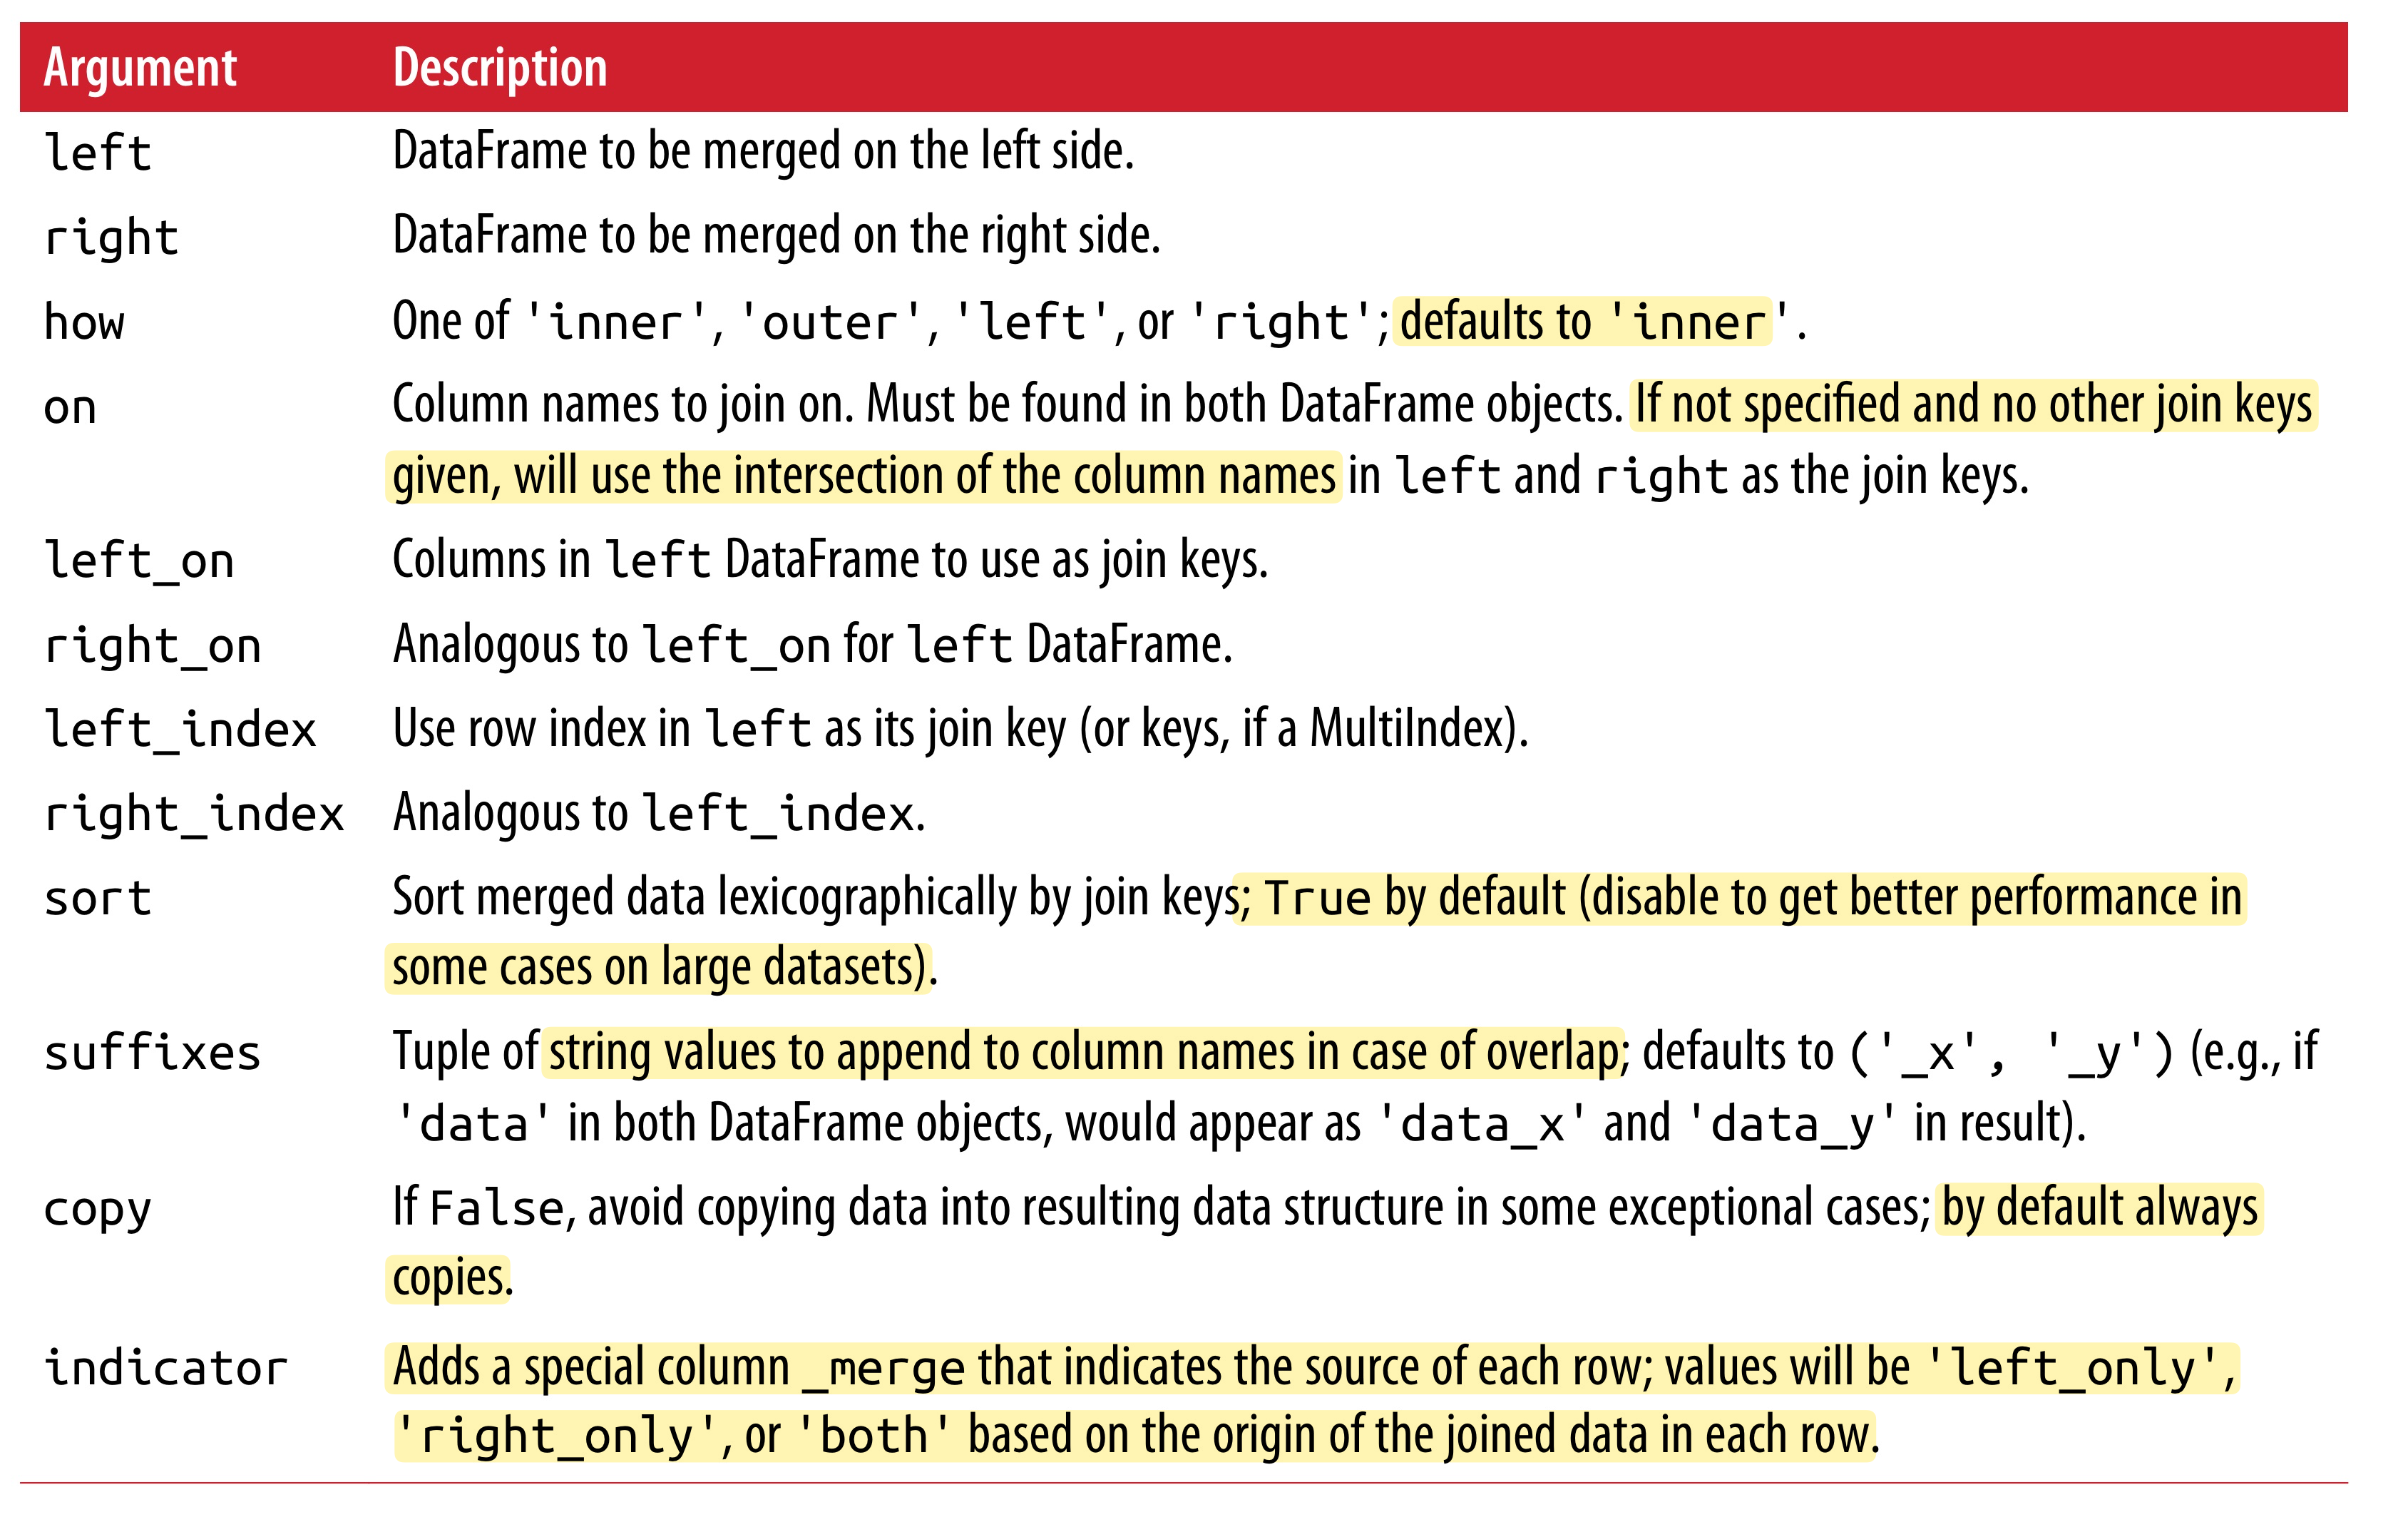

### Merging on Index (Row)

In [11]:
left1 = pd.DataFrame({'key':['a','b','a','a','b','c'], 
                      'value':range(6)})
right1 = pd.DataFrame({'group_val':[3.5,7]}, index=['a','b'])

In [12]:
pd.merge(left1, right1, left_on='key', right_index=True) # default->intersect, how='outer' 추가 가능

,key,value,group_val
0,a,0,3.5
2,a,2,3.5
3,a,3,3.5
1,b,1,7.0
4,b,4,7.0


In [13]:
left1.join(right1, on='key') # preserving the left frame's row index

,key,value,group_val
0,a,0,3.5
1,b,1,7.0
2,a,2,3.5
3,a,3,3.5
4,b,4,7.0
5,c,5,NaN


> - With hierarchically indexed data

In [2]:
lefth = pd.DataFrame({'key1':['Ohio','Ohio','Ohio','Nevada','Nevada'], 
                      'key2':[2000,2001,2002,2001,2002], 
                      'data':np.arange(5)})

righth = pd.DataFrame(np.arange(12).reshape((6,2)),
                      index=[['Nevada','Nevada','Ohio','Ohio','Ohio','Ohio'],
                             [2001,2000,2000,2000,2001,2002]],
                      columns=['event1','event2'])
lefth

,key1,key2,data
0,Ohio,2000,0
1,Ohio,2001,1
2,Ohio,2002,2
3,Nevada,2001,3
4,Nevada,2002,4


In [3]:
righth

event1  event2
Nevada 2001       0       1
       2000       2       3
Ohio   2000       4       5
       2000       6       7
       2001       8       9
       2002      10      11

In [4]:
pd.merge(lefth, righth, left_on=['key1','key2'], right_index=True, how='outer')

,key1,key2,data,event1,event2
0,Ohio,2000,0.0,4.0,5.0
0,Ohio,2000,0.0,6.0,7.0
1,Ohio,2001,1.0,8.0,9.0
2,Ohio,2002,2.0,10.0,11.0
3,Nevada,2001,3.0,0.0,1.0
4,Nevada,2002,4.0,NaN,NaN
4,Nevada,2000,NaN,2.0,3.0


> - Using the indexes of both sides of the merge is also possible:

In [8]:
left2 = pd.DataFrame([[1,2],[3,4],[5,6]], index=['a','c','e'],
                     columns=['Ohio','Nevada'])
right2 = pd.DataFrame([[7,8],[9,10],[11,12],[13,14]], index=['b','c','d','e'],
                     columns=['Missouri','Alabama'])

In [10]:
pd.merge(left2, right2, how='outer', left_index=True, right_index=True) # left2.join(right2, how='outer')

,Ohio,Nevada,Missouri,Alabama
a,1.0,2.0,NaN,NaN
b,NaN,NaN,7.0,8.0
c,3.0,4.0,9.0,10.0
d,NaN,NaN,11.0,12.0
e,5.0,6.0,13.0,14.0


> - For simple index-on-index merges, you can pass **a list of DataFrames** to ***join*** as an alternative to using the more general ***concat*** function

In [14]:
another = pd.DataFrame([[7,8],[9,10],[11,12],[16,17]], index=['a','c','e','f'],
                       columns=['New York','Oregon'])
another

,New York,Oregon
a,7,8
c,9,10
e,11,12
f,16,17


In [17]:
left2.join([right2, another]) # how='outer' 가능

,Ohio,Nevada,Missouri,Alabama,New York,Oregon
a,1.0,2.0,NaN,NaN,7.0,8.0
c,3.0,4.0,9.0,10.0,9.0,10.0
e,5.0,6.0,13.0,14.0,11.0,12.0


### Concatenating Along Axis

In [3]:
arr = np.arange(12).reshape((3,4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [6]:
np.concatenate([arr,arr], axis=1) # axis=1 -> 열방향으로 붙이기

array([[ 0,  1,  2,  3,  0,  1,  2,  3],
       [ 4,  5,  6,  7,  4,  5,  6,  7],
       [ 8,  9, 10, 11,  8,  9, 10, 11]])

> - Ex1 : Three Series with no index overlap:

In [2]:
s1 = pd.Series([0,1], index=['a','b'])
s2 = pd.Series([2,3,4], index=['c','d','e'])
s3 = pd.Series([5,6], index=['f','g'])

In [3]:
pd.concat([s1,s2,s3])

a    0
b    1
c    2
d    3
e    4
f    5
g    6
dtype: int64

In [4]:
pd.concat([s1,s2,s3], axis=1)

,0,1,2
a,0.0,NaN,NaN
b,1.0,NaN,NaN
c,NaN,2.0,NaN
d,NaN,3.0,NaN
e,NaN,4.0,NaN
f,NaN,NaN,5.0
g,NaN,NaN,6.0


- By default, ***concat*** works along axis=0, **producing another Series**.
- If you pass ***axis=1***, the result will instead **be a DataFrame**:

> - Ex2 : index overlap이 있는 경우
> - 교집합 index만 표기하기 위해서는 ***join='inner'*** 옵션 부여 가능

In [12]:
s4 = pd.concat([s1, s3])
pd.concat([s1, s4], axis=1) # or axis='columns'

,0,1
a,0.0,0
b,1.0,1
f,NaN,5
g,NaN,6


In [13]:
pd.concat([s1, s4], axis=1, join='inner')

,0,1
a,0,0
b,1,1


> - Ex3 : Suppose instead you wanted to create a hierarchical index on the concatenation axis. To do this, use the ***keys*** argument:

In [15]:
result = pd.concat([s1, s1, s3], keys=['one','two','three'])
result

one    a    0
       b    1
two    a    0
       b    1
three  f    5
       g    6
dtype: int64

In [16]:
result.unstack()

,a,b,f,g
one,0.0,1.0,NaN,NaN
two,0.0,1.0,NaN,NaN
three,NaN,NaN,5.0,6.0


> - In the case of combining Series along ***axis=1***, the ***keys*** become the DataFrame column headers:

In [17]:
pd.concat([s1, s1, s3], axis='columns', keys=['one','two','three'])

,one,two,three
a,0.0,0.0,NaN
b,1.0,1.0,NaN
f,NaN,NaN,5.0
g,NaN,NaN,6.0


> - The same logic extends to DataFrame objects:

In [19]:
df1 = pd.DataFrame(np.arange(6).reshape((3,2)), index=['a','b','c'], columns=['one','two'])
df1

,one,two
a,0,1
b,2,3
c,4,5


In [22]:
df2 = pd.DataFrame(5+np.arange(4).reshape(2,2), index=['a','c'], columns=['three','four'])
df2

,three,four
a,5,6
c,7,8


In [24]:
pd.concat([df1,df2], axis='columns', keys=['level1','level2'])
# pd.concat({'level1':df1, 'level2':df2}, axis='columns')

level1     level2     
     one two  three four
a      0   1    5.0  6.0
b      2   3    NaN  NaN
c      4   5    7.0  8.0

> - We can name the created axis levels with the ***names*** argument:
> - pd.concat([df1, df2], axis='columns', keys=['level1','level2], names=['upper','lower])

> - A last consideration concerns DataFrames in which the row index does not contain any relevant data:

In [25]:
df1 = pd.DataFrame(np.random.randn(3,4), columns=['a','b','c','d'])
df2 = pd.DataFrame(np.random.randn(2,3), columns=['b','d','a'])

In [26]:
pd.concat([df1, df2])

,a,b,c,d
0,0.415979,-0.253018,0.470863,0.232945
1,-0.677421,0.907484,1.245876,-0.099873
2,0.723761,-1.544390,-0.630266,-0.778932
0,-0.425972,-0.034694,NaN,0.246326
1,0.341255,-1.314025,NaN,0.142731


In [27]:
pd.concat([df1, df2], ignore_index=True)

,a,b,c,d
0,0.415979,-0.253018,0.470863,0.232945
1,-0.677421,0.907484,1.245876,-0.099873
2,0.723761,-1.544390,-0.630266,-0.778932
3,-0.425972,-0.034694,NaN,0.246326
4,0.341255,-1.314025,NaN,0.142731


> 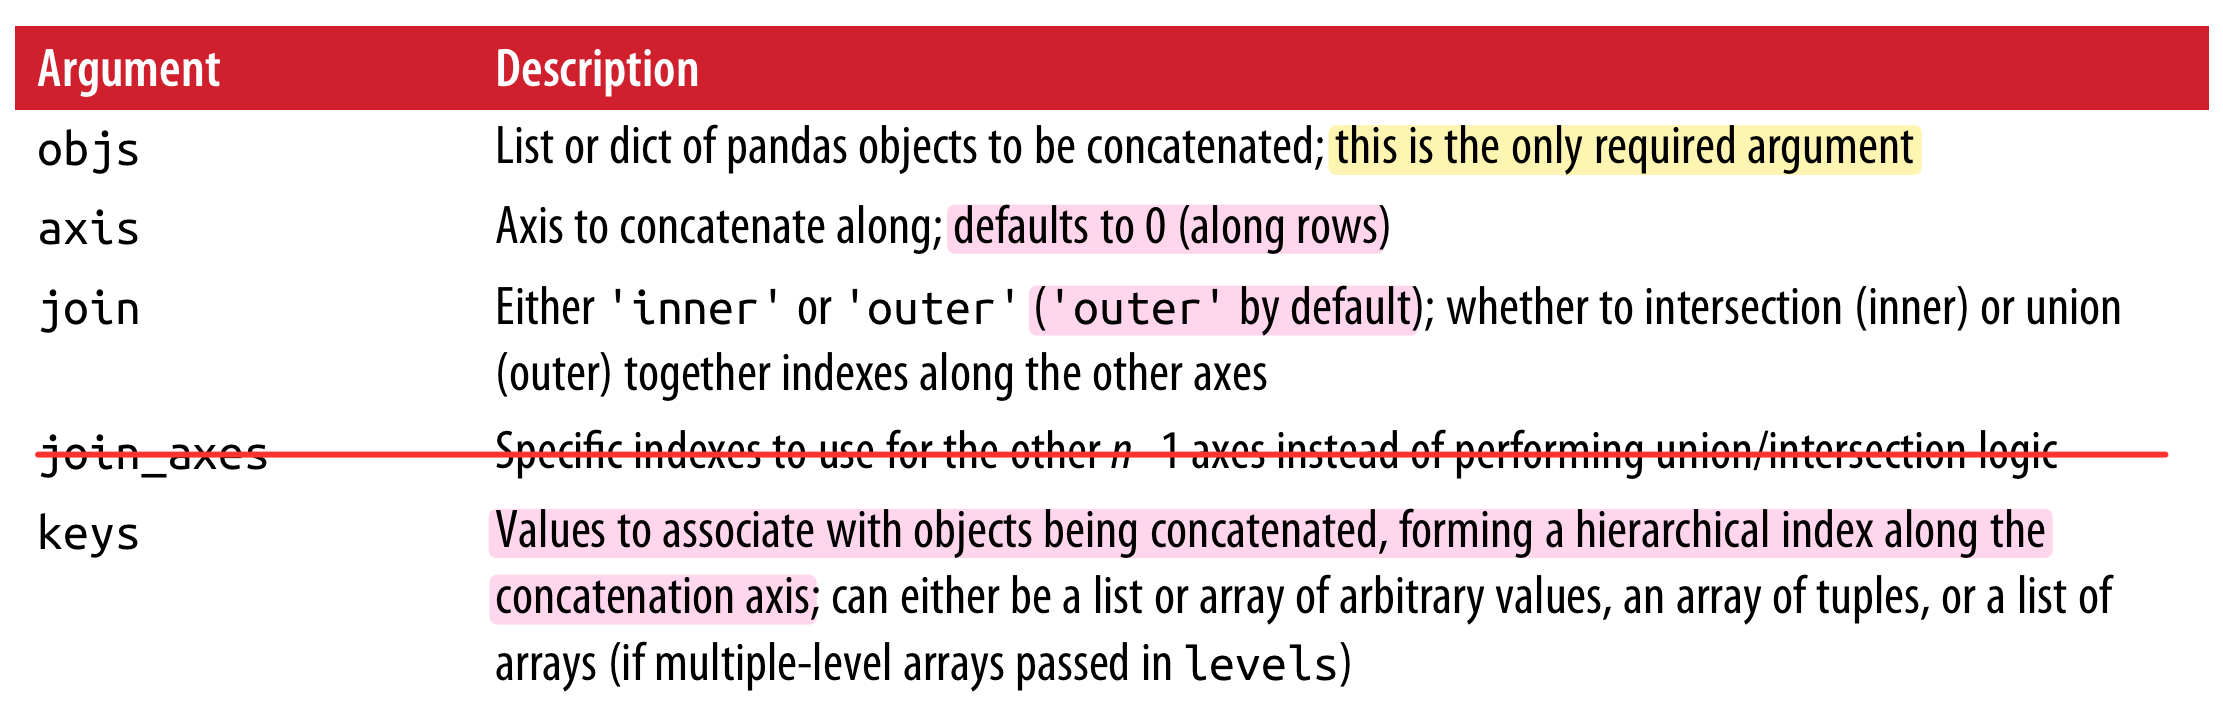
> 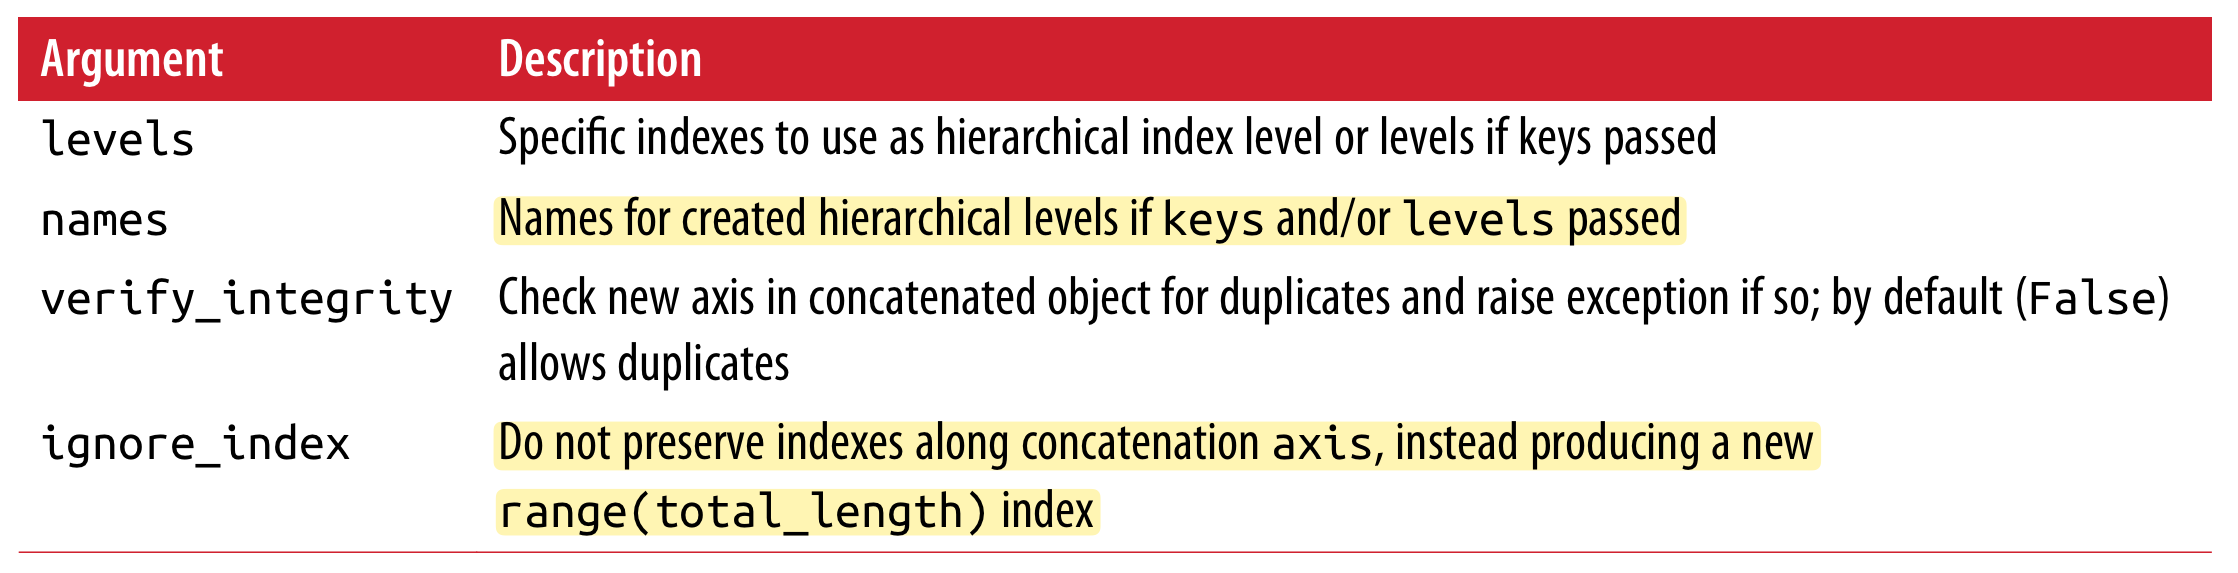

### Combining Data with Overlap

In [5]:
a = pd.Series([np.nan, 2.5, np.nan, 3.5, 4.5, np.nan], 
              index=['f','e','d','c','b','a'])
a

f    NaN
e    2.5
d    NaN
c    3.5
b    4.5
a    NaN
dtype: float64

In [7]:
b = pd.Series(np.arange(len(a), dtype=np.float64),
              index=['f','e','d','c','b','a'])
b[-1] = np.nan
b

f    0.0
e    1.0
d    2.0
c    3.0
b    4.0
a    NaN
dtype: float64

In [15]:
np.where(pd.isnull(a), b, a)

array([0. , 2.5, 2. , 3.5, 4.5, nan])

> - self.combine_first(other) // other의 값으로 self(df)의 NaN 값을 덮어쓰는 메서드
> - "patching" missing data in the calling object with data from the object you pass: 

In [19]:
# for Series
b[:-2].combine_first(a[2:])

a    NaN
b    4.5
c    3.0
d    2.0
e    1.0
f    0.0
dtype: float64

In [20]:
# for DataFrame
df1 = pd.DataFrame({'a':[1,np.nan,5,np.nan],
                    'b':[np.nan,2,np.nan,6], 
                    'c':range(2,18,4)})
df1

,a,b,c
0,1.0,NaN,2
1,NaN,2.0,6
2,5.0,NaN,10
3,NaN,6.0,14


In [21]:
df2 =  pd.DataFrame({'a':[5,4,np.nan,3,7],
                     'b':[np.nan,3,4,6,8]})
df2

,a,b
0,5.0,NaN
1,4.0,3.0
2,NaN,4.0
3,3.0,6.0
4,7.0,8.0


In [22]:
df1.combine_first(df2)

,a,b,c
0,1.0,NaN,2.0
1,4.0,2.0,6.0
2,5.0,4.0,10.0
3,3.0,6.0,14.0
4,7.0,8.0,NaN


## 8.3 Reshaping and Pivoting

### Reshaping with Hierarchical Indexing
> - ***stack*** : This **"rotates"** or pivots from the columns in the data to the rows
> - ***unstack*** : This pivots from the rows into the columns
> - By default **the innermost level is unstacked(same with stack)**. You can unstack a different level by passing a level number or name:

In [3]:
data = pd.DataFrame(np.arange(6).reshape((2,3)),
                    index=pd.Index(['Ohio','Colorado'],name='state'),
                    columns=pd.Index(['one','two','three'], name='number'))
data

number,one,two,three
state,,,
Ohio,0,1,2
Colorado,3,4,5


In [4]:
result = data.stack()
result

state     number
Ohio      one       0
          two       1
          three     2
Colorado  one       3
          two       4
          three     5
dtype: int64

In [11]:
result.unstack() # = result.unstack(1) = result.unstack('number')

number,one,two,three
state,,,
Ohio,0,1,2
Colorado,3,4,5


In [15]:
result.unstack(0) # = result.unstack('state')

state,Ohio,Colorado
number,,
one,0,3
two,1,4
three,2,5


> - Unstacking might introduce missing data if all of the values in the level aren't found in each of the subgroups:

In [18]:
s1 = pd.Series([0,1,2,3], index=['a','b','c','d'])

In [19]:
s2 = pd.Series([4,5,6], index=['c','d','e'])

In [24]:
data2 = pd.concat([s1,s2], keys=['one','two'])
data2

one  a    0
     b    1
     c    2
     d    3
two  c    4
     d    5
     e    6
dtype: int64

In [27]:
data2.unstack()

,a,b,c,d,e
one,0.0,1.0,2.0,3.0,NaN
two,NaN,NaN,4.0,5.0,6.0


In [30]:
data2.unstack().stack(dropna=False)

one  a    0.0
     b    1.0
     c    2.0
     d    3.0
     e    NaN
two  a    NaN
     b    NaN
     c    4.0
     d    5.0
     e    6.0
dtype: float64

- Stacking filters out missing data by default

> - When you unstack in a DataFrame, the level unstacked becomes the lowest level in the result:
> - When calling stack, **we can indicate the name of the axis to stack:**

In [32]:
df = pd.DataFrame({'left':result, 'right':result+5},
                  columns=pd.Index(['left','right'], name='side'))
df

side             left  right
state    number             
Ohio     one        0      5
         two        1      6
         three      2      7
Colorado one        3      8
         two        4      9
         three      5     10

In [33]:
df.unstack('state') # = df.unstack(0)

side   left          right         
state  Ohio Colorado  Ohio Colorado
number                             
one       0        3     5        8
two       1        4     6        9
three     2        5     7       10

In [34]:
df.unstack('state').stack('side')

state         Colorado  Ohio
number side                 
one    left          3     0
       right         8     5
two    left          4     1
       right         9     6
three  left          5     2
       right        10     7

### Pivoting "Long" to "Wide" Format

In [2]:
data = pd.read_csv('Examples/macrodata.csv')
data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [3]:
periods = pd.PeriodIndex(year=data.year, quarter=data.quarter, name='date')
periods

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', name='date', length=203)

In [4]:
columns = pd.Index(['realgdp','infl','unemp'], name='item') # 일부 열만 선택 1
columns

Index(['realgdp', 'infl', 'unemp'], dtype='object', name='item')

In [5]:
data = data.reindex(columns=columns) # 일부 열만 선택 2
data.head()

item,realgdp,infl,unemp
0,2710.349,0.00,5.8
1,2778.801,2.34,5.1
2,2775.488,2.74,5.3
3,2785.204,0.27,5.6
4,2847.699,2.31,5.2


In [6]:
data.index = periods.to_timestamp('D', 'end')
data.head()

item,realgdp,infl,unemp
date,,,
1959-03-31 23:59:59.999999999,2710.349,0.00,5.8
1959-06-30 23:59:59.999999999,2778.801,2.34,5.1
1959-09-30 23:59:59.999999999,2775.488,2.74,5.3
1959-12-31 23:59:59.999999999,2785.204,0.27,5.6
1960-03-31 23:59:59.999999999,2847.699,2.31,5.2


In [7]:
# method 하나씩 붙여보면서 df의 변화 과정 살펴보면 좋음
ldata = data.stack().reset_index().rename(columns={0:'value'}) 
ldata.head()

,date,item,value
0,1959-03-31 23:59:59.999999999,realgdp,2710.349
1,1959-03-31 23:59:59.999999999,infl,0.000
2,1959-03-31 23:59:59.999999999,unemp,5.800
3,1959-06-30 23:59:59.999999999,realgdp,2778.801
4,1959-06-30 23:59:59.999999999,infl,2.340


> - You might prefer to have a DataFrame containing one column per distinct **item** value indexed by timestamps in the **date** column. DataFrame's ***pivot*** method performs exactly this transformation:
> - The first two values passed are the columns to be used respectively **as the row and column index**, then finally an optional value column to fill the DataFrame.

In [17]:
pivoted = ldata.pivot(index='date', columns='item', values='value')
pivoted

item,infl,realgdp,unemp
date,,,
1959-03-31 23:59:59.999999999,0.00,2710.349,5.8
1959-06-30 23:59:59.999999999,2.34,2778.801,5.1
1959-09-30 23:59:59.999999999,2.74,2775.488,5.3
1959-12-31 23:59:59.999999999,0.27,2785.204,5.6
1960-03-31 23:59:59.999999999,2.31,2847.699,5.2
...,...,...,...
2008-09-30 23:59:59.999999999,-3.16,13324.600,6.0
2008-12-31 23:59:59.999999999,-8.79,13141.920,6.9
2009-03-31 23:59:59.999999999,0.94,12925.410,8.1


In [9]:
ldata['value2'] = np.random.rand(len(ldata))
ldata

,date,item,value,value2
0,1959-03-31 23:59:59.999999999,realgdp,2710.349,0.463709
1,1959-03-31 23:59:59.999999999,infl,0.000,0.018751
2,1959-03-31 23:59:59.999999999,unemp,5.800,0.425709
3,1959-06-30 23:59:59.999999999,realgdp,2778.801,0.449740
4,1959-06-30 23:59:59.999999999,infl,2.340,0.872385
...,...,...,...,...
604,2009-06-30 23:59:59.999999999,infl,3.370,0.848135
605,2009-06-30 23:59:59.999999999,unemp,9.200,0.334126
606,2009-09-30 23:59:59.999999999,realgdp,12990.341,0.946929
607,2009-09-30 23:59:59.999999999,infl,3.560,0.421628


> - By **omitting the last argument**, you obtain a DataFrame with hierarchical columns:

In [10]:
pivoted = ldata.pivot('date','item')
pivoted

value                     value2            \
item                           infl    realgdp unemp      infl   realgdp   
date                                                                       
1959-03-31 23:59:59.999999999  0.00   2710.349   5.8  0.018751  0.463709   
1959-06-30 23:59:59.999999999  2.34   2778.801   5.1  0.872385  0.449740   
1959-09-30 23:59:59.999999999  2.74   2775.488   5.3  0.827124  0.347414   
1959-12-31 23:59:59.999999999  0.27   2785.204   5.6  0.703731  0.299896   
1960-03-31 23:59:59.999999999  2.31   2847.699   5.2  0.786134  0.869682   
...                             ...        ...   ...       ...       ...   
2008-09-30 23:59:59.999999999 -3.16  13324.600   6.0  0.890485  0.171632   
2008-12-31 23:59:59.999999999 -8.79  13141.920   6.9  0.067172  0.976196   
2009-03-31 23:59:59.999999999  0.94  12925.410   8.1  0.387521  0.949878   
2009-06-30 23:59:59.999999999  3.37  12901.504   9.2  0.848135  0.440645   
2009-09-30 23:59:59.999999999  3.56  12990.341   9.6  0.421628  0.946929   

                                         
item                              unemp  
date                                     
1959-03-31 23:59:59.999999999  0.425709  
1959-06-30 23:59:59.999999999  0.175661  
1959-09-30 23:59:59.999999999  0.230586  
1959-12-31 23:59:59.999999999  0.438624  
1960-03-31 23:59:59.999999999  0.855668  
...                                 ...  
2008-09-30 23:59:59.999999999  0.618978  
2008-12-31 23:59:59.999999999  0.214965  
2009-03-31 23:59:59.999999999  0.736503  
2009-06-30 23:59:59.999999999  0.334126  
2009-09-30 23:59:59.999999999  0.248514  

[203 rows x 6 columns]

> - Note that ***pivot*** is equivalent to creating a hierarchical index using ***set_index*** followed by a call to ***unstack***:

In [18]:
# method 하나씩 붙여보면서 df의 변화 과정 살펴보면 좋음
unstacked = ldata.set_index(['date','item']).unstack(level='item')
unstacked

value                     value2            \
item                           infl    realgdp unemp      infl   realgdp   
date                                                                       
1959-03-31 23:59:59.999999999  0.00   2710.349   5.8  0.018751  0.463709   
1959-06-30 23:59:59.999999999  2.34   2778.801   5.1  0.872385  0.449740   
1959-09-30 23:59:59.999999999  2.74   2775.488   5.3  0.827124  0.347414   
1959-12-31 23:59:59.999999999  0.27   2785.204   5.6  0.703731  0.299896   
1960-03-31 23:59:59.999999999  2.31   2847.699   5.2  0.786134  0.869682   
...                             ...        ...   ...       ...       ...   
2008-09-30 23:59:59.999999999 -3.16  13324.600   6.0  0.890485  0.171632   
2008-12-31 23:59:59.999999999 -8.79  13141.920   6.9  0.067172  0.976196   
2009-03-31 23:59:59.999999999  0.94  12925.410   8.1  0.387521  0.949878   
2009-06-30 23:59:59.999999999  3.37  12901.504   9.2  0.848135  0.440645   
2009-09-30 23:59:59.999999999  3.56  12990.341   9.6  0.421628  0.946929   

                                         
item                              unemp  
date                                     
1959-03-31 23:59:59.999999999  0.425709  
1959-06-30 23:59:59.999999999  0.175661  
1959-09-30 23:59:59.999999999  0.230586  
1959-12-31 23:59:59.999999999  0.438624  
1960-03-31 23:59:59.999999999  0.855668  
...                                 ...  
2008-09-30 23:59:59.999999999  0.618978  
2008-12-31 23:59:59.999999999  0.214965  
2009-03-31 23:59:59.999999999  0.736503  
2009-06-30 23:59:59.999999999  0.334126  
2009-09-30 23:59:59.999999999  0.248514  

[203 rows x 6 columns]

### Pivoting "Wide" to "Long" Format
> - **An inverse operation to *pivot*** for DataFrame is ***pandas.melt***.
> - Rather than transforming one column into many in a new DataFrame, it merges multiple columns into one, producing a DataFrame that is longer than the input.

In [19]:
df = pd.DataFrame({'key':['foo','bar','baz'], 'A':[1,2,3],
                   'B':[4,5,6], 'C':[7,8,9]})
df

,key,A,B,C
0,foo,1,4,7
1,bar,2,5,8
2,baz,3,6,9


> - When using ***pandas.melt***, we must indicate which columns (if any) are group indicators.

In [20]:
melted = pd.melt(df, id_vars=['key'])
melted

,key,variable,value
0,foo,A,1
1,bar,A,2
2,baz,A,3
3,foo,B,4
4,bar,B,5
5,baz,B,6
6,foo,C,7
7,bar,C,8
8,baz,C,9


> - Using pivot, we can reshape back to the ***original layout***:

In [21]:
reshaped = melted.pivot(index='key',columns='variable',values='value')
reshaped

variable,A,B,C
key,,,
bar,2,5,8
baz,3,6,9
foo,1,4,7


In [22]:
reshaped.reset_index()

variable,key,A,B,C
0,bar,2,5,8
1,baz,3,6,9
2,foo,1,4,7


> - You can also specify a subset of columns to use as value columns:

In [25]:
pd.melt(df, id_vars=['key'], value_vars=['A','C'])

,key,variable,value
0,foo,A,1
1,bar,A,2
2,baz,A,3
3,foo,C,7
4,bar,C,8
5,baz,C,9


> - *pandas.melt* can be used **without any group identifiers,** too:

In [26]:
pd.melt(df, value_vars=['A','B','C'])

,variable,value
0,A,1
1,A,2
2,A,3
3,B,4
4,B,5
5,B,6
6,C,7
7,C,8
8,C,9


In [27]:
pd.melt(df, value_vars=['key','A','B'])

,variable,value
0,key,foo
1,key,bar
2,key,baz
3,A,1
4,A,2
5,A,3
6,B,4
7,B,5
8,B,6
